In [1]:
library(Signac)
library(Seurat)
library(BSgenome.Mmusculus.UCSC.mm10)
library(dplyr)
library(FNN)
library(chromVAR)
library(doParallel)
library(BuenColors)
library(FigR)
library(scater)
#####################
set.seed(4180)
setwd("/")
cols <- c("#444576", "#4682B4",
 "#AEDEEE","#FFA500",
 "#FFD790","#C65762","#FBDFDE",
 "#F6EFCF","#BCB99F")
pal <- colorRampPalette(cols)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: BSgenome

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    u

In [2]:
vCM <- readRDS("data/vCM.Rds")
sub_obj <- subset(vCM, subtype %in% "vCM-2")
sub_obj
library(GenomeInfoDb)
DefaultAssay(sub_obj) <- "RNA"
set.seed(4180)
ATAC.se <- SummarizedExperiment(
 assays = SimpleList(counts = sub_obj@assays$ATAC$counts),
 rowRanges = sub_obj@assays$ATAC@ranges,
 colData = sub_obj@meta.data
)
rnaMat <- GetAssayData(subset(sub_obj), assay = "RNA", layer = "data")
cisCor <- runGenePeakcorr(
 ATAC.se = ATAC.se,
 RNAmat = rnaMat,
 genome = "mm10", # Also supports hg19 and hg38
 nCores = 30,
 p.cut = NULL
)

An object of class Seurat 
218744 features across 10696 samples within 2 assays 
Active assay: RNA (26111 features, 2000 variable features)
 3 layers present: data, counts, scale.data
 1 other assay present: ATAC
 7 dimensional reductions calculated: pca, harmony, rlsi, lsi, umap, RNA.umap, ATAC.umap

Assuming paired scATAC/scRNA-seq data ..



Matrix object input detectedCentering counts for cells sequentially in groups of size  1000  ..

Computing centered counts for cells:  1  to  1000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  1001  to  2000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  2001  to  3000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  3001  to  4000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  4001  to  5000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  5001  to  6000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  6001  to  7000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  

Peaks with 0 accessibility across cells exist ..

Removing these peaks prior to running correlations ..

Important: peak indices in returned gene-peak maps are relative to original input SE

Genes with 0 expression across cells exist ..

Removing these genes prior to running correlations ..



Number of peaks in ATAC data: 192578 
Number of genes in RNA data: 22617 

Num genes overlapping TSS annotation and RNA matrix being considered:  18933 

Taking peak summits from peak windows ..
Finding overlapping peak-gene pairs ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL456210_random, chr1_GL456211_random, chr1_GL456212_random, chr1_GL456221_random, chr4_GL456216_random, chr4_GL456350_random, chr4_JH584292_random, chr4_JH584293_random, chr4_JH584294_random, chr4_JH584295_random, chr5_GL456354_random, chr5_JH584296_random, chr5_JH584297_random, chr5_JH584298_random, chr5_JH584299_random, chr7_GL456219_random, chrX_GL456233_random, chrY_JH584300_random, chrY_JH584301_random, chrY_JH584302_random, chrUn_GL456366, chrUn_GL456372, chrUn_JH584304
  - in 'y': GL456211.1, GL456216.1, GL456233.1, JH584292.1, JH584295.1, JH584304.1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


Found  253581 total gene-peak pairs for given TSS window ..
Number of peak summits that overlap any gene TSS window:  124698 
Number of gene TSS windows that overlap any peak summit:  18414 

Determining background peaks ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_GL455997_alt, chr10_GL456015_alt, chr

Using  100  iterations ..

Computing gene-peak correlations ..
Running pairs:  1 to 5000 
Running in parallel using  30 cores ..
Computing observed correlations ..
Finished!

Time Elapsed:  12.519807100296 secs 

Computing background correlations ..

Time Elapsed:  20.267702237765 mins 

Running pairs:  5001 to 10000 
Running in parallel using  30 cores ..
Computing observed correlations ..
Finished!

Time Elapsed:  10.0752718448639 secs 

Computing background correlations ..

Time Elapsed:  17.8445007165273 mins 

Running pairs:  10001 to 15000 
Running in parallel using  30 cores ..
Computing observed correlations ..
Finished!

Time Elapsed:  11.0579950809479 secs 

Computing background correlations ..

Time Elapsed:  18.0536193927129 mins 

Running pairs:  15001 to 20000 
Running in parallel using  30 cores ..
Computing observed correlations ..
Finished!

Time Elapsed:  10.3354444503784 secs 

Computing background correlations ..

Time Elapsed:  17.1762823859851 mins 

Running pairs

In [5]:
sub_obj[['RNA']] <- JoinLayers(sub_obj[['RNA']])
sub_obj[['RNA']] <- split(sub_obj[['RNA']],f=sub_obj$orig.ident)
sub_obj <- sub_obj %>%
 NormalizeData() %>%
 FindVariableFeatures(vars.to.regress =c("percent.mt", "percent.rb", "percent.hsp")) %>%
 ScaleData()%>%
 RunPCA()
sub_obj <- IntegrateLayers(
 object = sub_obj, method = HarmonyIntegration,
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)
sub_obj[['RNA']] <- JoinLayers(sub_obj[['RNA']])

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.

Normalizing layer: counts.NP1

Normalizing layer: counts.NP2

Normalizing layer: counts.NP3

Normalizing layer: counts.EP1

Normalizing layer: counts.EP2

Normalizing layer: counts.EP3

Normalizing layer: counts.MP1

Normalizing layer: counts.MP2

Normalizing layer: counts.MP3

Normalizing layer: counts.LP1

Normalizing layer: counts.LP2

Normalizing layer: counts.LP3

Normalizing layer: counts.PP1

Normalizing layer: counts.PP2

Normalizing layer: counts.PP3

Finding variable features for layer counts.NP1

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.7275”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.30103”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition nu

Running DORC scoring for 340 genes: Fhl2, Tns1, Ablim1, Atp2a2, Actn2, Sorbs1, Ryr2, Myocd, Tmtc1, Msi2, Nr4a1, Cdh2, Pik3r1, Slc8a1, Sptbn1, Txnip, Acacb, Angpt1, Dlc1, Lrtm1, ... , ... , ... (truncated display)



........
Normalizing scATAC counts ..
SummarizedExperiment object input detected .. Centering counts under assayCentering counts for cells sequentially in groups of size  5000  ..

Computing centered counts for cells:  1  to  5000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  5001  to  10000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  10001  to  10696 ..
Computing centered counts per cell using mean reads in features ..

Merging results..
Done!
Computing DORC scores ..
Running in parallel using  30 cores ..

Time Elapsed:  29.9125664234161 secs 

Number of cells in supplied matrix:  10696 
Number of genes in supplied matrix:  340 
Number of nearest neighbors being used per cell for smoothing:  20 
  |                                                                      |   0%Running in parallel using  30 cores ..
  |============================================

Assuming peak indices in Peak field

Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_

Getting peak x motif matches ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_GL455997_alt, chr10_GL456015_alt, chr

Determining background peaks ..
Using  50  iterations ..

Testing  703  TFs
Testing  340  DORCs


Running FigR using 30 cores ..




  |======================================================================| 100%Finished!
Merging results ..


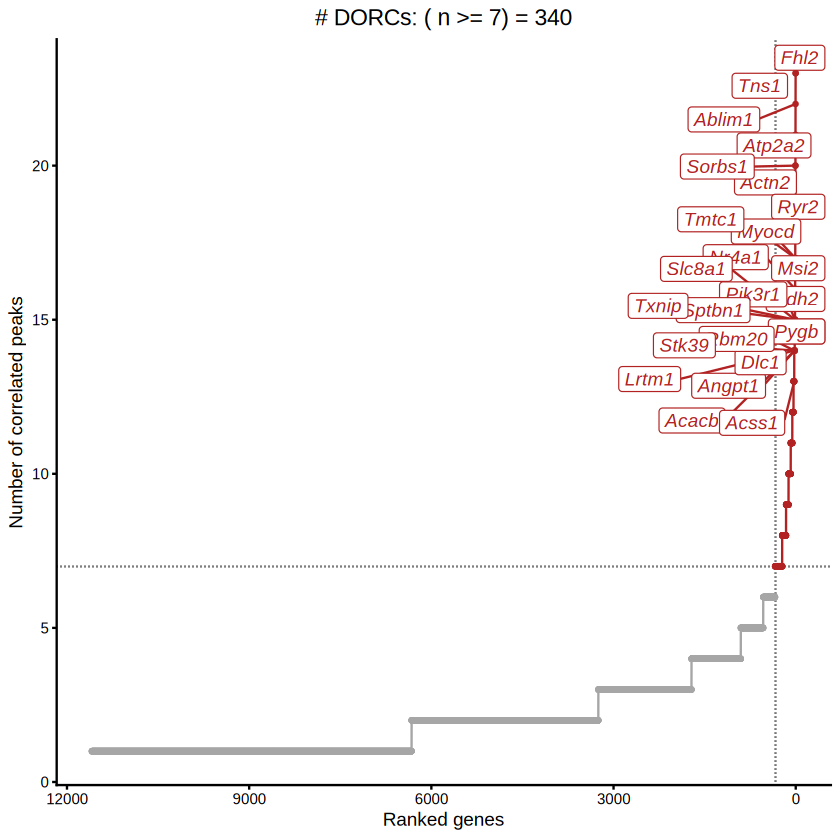

In [6]:
# Filter peak-gene correlations by p-value
cisCor.filt <- cisCor %>% filter(pvalZ <= 0.05)
# Determine DORC genes
dorcGenes <- cisCor.filt %>% dorcJPlot(
 cutoff = 7, # Default
 returnGeneList = TRUE
)
# Get DORC scores
dorcMat <- getDORCScores(ATAC.se, dorcTab = cisCor.filt, geneList = dorcGenes, nCores = 30)
# This takes longer since it's all genes
cellkNN <- FNN::get.knn(sub_obj@reductions$harmony@cell.embeddings, k = 30)$nn.index
rownames(cellkNN) <- colnames(rnaMat)
dorcMat.s <- smoothScoresNN(NNmat = cellkNN[, 1:20], mat = dorcMat, nCores = 30)
# Smooth RNA using cell KNNs
# This takes longer since it's all genes
RNAmat.s <- smoothScoresNN(NNmat = cellkNN[, 1:20], mat = rnaMat, nCores = 30)
# Run FigR
figR.d <- runFigRGRN(ATAC.se = ATAC.se, # Must be the same input as used in runGenePeakcorr()
 dorcTab = cisCor.filt, # Filtered peak-gene associations
 genome = "mm10",
 dorcMat = dorcMat.s,
 rnaMat = RNAmat.s,
 nCores = 30)
saveRDS(figR.d, "data/vCM2_figR.rds")

In [2]:
figR.d <- readRDS("data/vCM2_figR.rds")

In [8]:
rank <- rankDrivers(figR.d, rankBy = "meanScore",myLabels = "Esrra")
rank$data$Motif

Ranking TFs by mean regulation score across all DORCs ..


Warning message in geom_bar(size = 0.1, stat = "identity", fill = "darkorange", :
“Ignoring unknown parameters: `size`”


[1] Tcf12    Zbtb18   Nr1d2    Nr2c2    Atf1     Rreb1    Hmg20a   Pou5f1  
  [9] Nfia     Esrra    Nr2c1    Nr2f6    Hmg20b   Mlxip    Atf6     Zkscan1 
 [17] Nfe2l2   Rfx7     Esrrg    Npas2    Ybx2     Ikzf2    Usf2     Thrb    
 [25] Arid2    Bhlhe40  Cux2     Kdm2a    Nr1d1    Tet3     Atf2     Crem    
 [33] Cux1     Sp3      Rxrb     Esrrb    Zfp322a  Zfp110   Klf9     Plagl2  
 [41] Zfp932   Arnt     Zfp523   Zzz3     Ppara    Mnt      Zfp282   Foxo1   
 [49] Foxk2    Prdm5    Atf7     Zfp276   Zfp691   Dpf3     Max      Gata6   
 [57] Zbtb26   Nr6a1    Mga      Rxrg     Sox6     Tfeb     Stat5b   Cbfb    
 [65] Atf4     Zscan26  Nr3c1    Clock    Mitf     Nfib     Ets2     Sohlh2  
 [73] Hlf      Rorc     Rxra     Zbtb1    Ebf3     Foxj3    Hif1a    Rarb    
 [81] Tef      Zfp383   Cdc5l    Bbx      Xbp1     Nfic     Nfe2l1   Ahctf1  
 [89] Zbtb7b   Tbx20    E2f8     Zfp212   Irf2     Zfp768   Zfp398   Zbtb12  
 [97] Pou2f1   Tbx2     Tet1     Kdm2b    Prox1    Smad5    Irf3     Zfp46   
[105] Zfp281   Tcf7l2   Foxp1    Zfp771   Prox2    Tead1    Zfp1     Stat6   
[113] Nr1i3    Bcl6b    Crebl2   Pax5     Mbd2     Hand2    Mynn     Tbx5    
[121] Hsf2     Zbtb14   Mecp2    Zbtb2    Zeb1     Rfx3     Etv6     Gmeb1   
[129] Zfp146   Phf21a   Zfp3     Tbp      Creb1    Tbx6     Nfat5    Mecom   
[137] Zfp692   Prrxl1   Arid3b   Six5     Klf3     Ybx3     Creb3l2  Zfp641  
[145] Atf6b    Rfx5     Srebf1   Hhex     Dnajc21  Mypop    Rbpj     Vezf1   
[153] Foxn3    Lcor     Foxj2    Elf2     Sox7     Grhl2    Rfx1     Zbtb37  
[161] Zbtb3    Bhlhe41  Kmt2a    Jund     Pax6     Zfp13    Hinfp    Msantd3 
[169] Smad4    Hnf1b    Zfp770   Zscan29  Plag1    Nfix     Meox2    Pitx2   
[177] Terf2    Klf10    Ddit3    Taf1     Tal2     Gata2    Pax4     Zfp384  
[185] Stat5a   Foxm1    Gata4    Klf12    Meis1    Zbtb20   Nrf1     Zfp296  
[193] Zfp524   Zfp449   Mlx      Klf6     Foxo3    Zkscan5  Batf     Zfp202  
[201] Mlxipl   Creb5    Zeb2     Zfp317   Sp2      Stat3    Rel      Ybx1    
[209] Etv3     Bhlhe22  Zfp182   Zbtb33   Creb3l1  Nfatc2   Msc      Klf13   
[217] Hmbox1   Pgr      Smad1    E2f3     Mef2d    Tfcp2    Gmeb2    Zfp647  
[225] Foxp2    Crx      Prrx2    Prdm11   Irx2     Runx2    Meis2    Lin28b  
[233] Myc      Zfp777   Ets1     Elf1     Mef2a    Tfec     Irx1     Pax2    
[241] Tfe3     Nfatc4   Sp4      Irx3     Nfatc1   Mxd1     Snai3    Ovol2   
[249] Rela     Gabpa    Bcl6     Zbtb7a   Spib     Mef2c    Hoxa7    Prdm9   
[257] Stat2    Zkscan17 Hey1     Nkx11    Borcs8   Elk4     Pbx3     Irx5    
[265] Tigd2    Dbp      Hoxd3    Crebzf   Zfp113   Irf9     Zfp711   Egr3    
[273] Irx4     Zfp143   Twist1   Rora     Sp100    Nfkb2    Zfp410   Bcl11a  
[281] Tcf3     Cxxc1    Rfx2     Nfil3    Gata3    Zfp566   Barx2    Lhx8    
[289] Mbtps2   Zfp422   Prdm1    Hsf5     Sox30    Isx      Klf1     Nfkb1   
[297] Myrf     Tfap2c   Rhox8    Nfatc3   Hoxb4    Zfp64    Zfp652   Zfp580  
[305] Sox4     Mafb     Nanog    Irf4     Zfp174   Zfp454   Pou6f1   Meis3   
[313] Lcorl    Dnmt1    Hoxd11   Zfp260   Ubp1     Tbx18    Mef2b    Egr2    
[321] Erg      Hsf1     Creb3    Hey2     Tgif2    Fli1     Erf      Emx1    
[329] Jrkl     Nkx25    Hlx      Hoxc6    Zfp324   Hes1     Pou4f1   Nfe2    
[337] Arid3a   Pou2f2   Sp1      Msx2     Foxf2    Klf7     Arid5a   Lin54   
[345] Gbx1     Ikzf3    Arntl    Phox2a   Etv1     Zfp661   Hoxc8    Tbr1    
[353] Zkscan6  Pbx4     Zfp287   Pax7     Bsx      Pknox1   Emx2     Cebpg   
[361] Zbtb7c   Hmx2     Sp9      Zic4     Otp      Stat4    Ctcfl    Trp73   
[369] Tbx15    Hes7     Glis3    Zfp42    Irf7     Six1     Sox17    E2f7    
[377] Ctcf     Foxp4    Six4     Zbtb45   Elk3     Sox9     Hoxa5    Mzf1    
[385] Zfx      Zfp263   Zfp637   Isl1     Pax3     Zfp189   Zik1     Nr3c2   
[393] Nfyc     E2f1     Zic2     Prrx1    Atoh7    Nr1i2    Mnx1     Lin28a  
[401] Ehf      Fosl2    Barhl1   Zfp423   Elf4     Dlx5     Zfp128   Nr1h2   
[409] Hoxd4    E2f5     

In [4]:
subsc.list <- readRDS("data/subsc.list.Rds")

In [5]:
library(GenomeInfoDb)
EC <- subsc.list[[3]]
EC[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(EC)][['ATAC']]
sub_obj <- subset(EC,subtype %in% "EC-2")
DefaultAssay(sub_obj) <- "RNA"
sub_obj <- sub_obj[,sample(colnames(sub_obj),2000)]
set.seed(4180)
sub_obj[['RNA']] <- split(sub_obj[['RNA']],f=sub_obj$orig.ident)
sub_obj <- sub_obj %>%
 NormalizeData() %>%
 FindVariableFeatures() %>%
 ScaleData(vars.to.regress = c("percent.mt", "percent.rb", "percent.hsp"))%>%
 RunPCA()
sub_obj <- IntegrateLayers(
 object = sub_obj, method = HarmonyIntegration,
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)
sub_obj[['RNA']] <- JoinLayers(sub_obj[['RNA']])
ATAC.se <- SummarizedExperiment(
 assays = SimpleList(counts = sub_obj@assays$ATAC$counts),
 rowRanges = sub_obj@assays$ATAC@ranges,
 colData = sub_obj@meta.data
)
rnaMat <- GetAssayData(subset(sub_obj), assay = "RNA", layer = "data")
cisCor <- runGenePeakcorr(
 ATAC.se = ATAC.se,
 RNAmat = rnaMat,
 genome = "mm10", # Also supports hg19 and hg38
 nCores = 30,
 p.cut = NULL
)
# Filter peak-gene correlations by p-value
cisCor.filt <- cisCor %>% filter(pvalZ <= 0.05)
# Determine DORC genes
dorcGenes <- cisCor.filt %>% dorcJPlot(
 cutoff = 7, # Default
 returnGeneList = TRUE
)
# Get DORC scores
dorcMat <- getDORCScores(ATAC.se, dorcTab = cisCor.filt, geneList = dorcGenes, nCores = 30)
# This takes longer since it's all genes
cellkNN <- FNN::get.knn(sub_obj@reductions$harmony@cell.embeddings, k = 30)$nn.index
rownames(cellkNN) <- colnames(rnaMat)
dorcMat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = dorcMat, nCores = 30)
# Smooth RNA using cell KNNs
# This takes longer since it's all genes
RNAmat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = rnaMat, nCores = 30)
# Run FigR
figR.d <- runFigRGRN(ATAC.se = ATAC.se, # Must be the same input as used in runGenePeakcorr()
 dorcTab = cisCor.filt, # Filtered peak-gene associations
 genome = "mm10",
 dorcMat = dorcMat.s,
 rnaMat = RNAmat.s,
 nCores = 30)
saveRDS(figR.d, "data/EC2_figR.rds")

Splitting ‘counts’, ‘data’ layers. Not splitting ‘scale.data’. If you would like to split other layers, set in `layers` argument.

Normalizing layer: counts.NP1

Normalizing layer: counts.NP2

Normalizing layer: counts.NP3

Normalizing layer: counts.EP1

Normalizing layer: counts.EP2

Normalizing layer: counts.EP3

Normalizing layer: counts.MP1

Normalizing layer: counts.MP2

Normalizing layer: counts.MP3

Normalizing layer: counts.LP1

Normalizing layer: counts.LP2

Normalizing layer: counts.LP3

Normalizing layer: counts.PP1

Normalizing layer: counts.PP2

Normalizing layer: counts.PP3

Finding variable features for layer counts.NP1

Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at -2.0383”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.3181”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition num

Matrix object input detectedCentering counts for cells sequentially in groups of size  1000  ..

Computing centered counts for cells:  1  to  1000 ..
Computing centered counts per cell using mean reads in features ..

Computing centered counts for cells:  1001  to  2000 ..
Computing centered counts per cell using mean reads in features ..

Merging results..
Done!


Peaks with 0 accessibility across cells exist ..

Removing these peaks prior to running correlations ..

Important: peak indices in returned gene-peak maps are relative to original input SE

Genes with 0 expression across cells exist ..

Removing these genes prior to running correlations ..



Number of peaks in ATAC data: 185796 
Number of genes in RNA data: 18670 

Num genes overlapping TSS annotation and RNA matrix being considered:  16210 

Taking peak summits from peak windows ..
Finding overlapping peak-gene pairs ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL456210_random, chr1_GL456211_random, chr1_GL456212_random, chr1_GL456221_random, chr4_GL456216_random, chr4_GL456350_random, chr4_JH584292_random, chr4_JH584293_random, chr4_JH584294_random, chr4_JH584295_random, chr5_GL456354_random, chr5_JH584296_random, chr5_JH584297_random, chr5_JH584298_random, chr5_JH584299_random, chr7_GL456219_random, chrX_GL456233_random, chrY_JH584300_random, chrY_JH584301_random, chrY_JH584302_random, chrUn_GL456366, chrUn_GL456372, chrUn_JH584304
  - in 'y': GL456211.1, GL456216.1, GL456233.1, JH584292.1, JH584295.1, JH584304.1
  Make sure to always combine/compare objects based on the same reference
  genome (use suppressWarnings() to suppress this warning).”


Found  221722 total gene-peak pairs for given TSS window ..
Number of peak summits that overlap any gene TSS window:  114044 
Number of gene TSS windows that overlap any peak summit:  15900 

Determining background peaks ..


Warning message in .merge_two_Seqinfo_objects(x, y):
“Each of the 2 combined objects has sequence levels not in the other:
  - in 'x': chrM, chr1_GL455991_alt, chr1_GL455992_alt, chr1_GL455993_alt, chr1_GL456005_alt, chr1_JH584315_alt, chr1_JH584320_alt, chr1_JH584321_alt, chr1_JH584322_alt, chr2_GL456024_alt, chr3_GL456006_alt, chr3_GL456007_alt, chr3_GL456008_alt, chr3_GL456042_alt, chr3_GL456044_alt, chr3_GL456045_alt, chr3_GL456048_alt, chr3_GL456049_alt, chr3_JH584323_alt, chr4_GL455994_alt, chr4_GL456009_alt, chr4_GL456010_alt, chr4_GL456053_alt, chr4_GL456064_alt, chr4_GL456075_alt, chr4_GL456076_alt, chr4_GL456077_alt, chr4_JH584268_alt, chr4_JH584269_alt, chr4_JH584324_alt, chr4_JH584325_alt, chr4_JH584326_alt, chr5_GL455995_alt, chr5_GL456011_alt, chr6_GL456012_alt, chr6_GL456025_alt, chr6_GL456026_alt, chr6_GL456054_alt, chr6_GL456065_alt, chr6_JH584264_alt, chr7_GL455989_alt, chr7_GL456013_alt, chr7_GL456014_alt, chr8_GL455996_alt, chr8_GL455997_alt, chr10_GL456015_alt, chr

In [ ]:
library(GenomeInfoDb)
FB <- subsc.list[[2]]
FB[["ATAC"]] <- readRDS("data/mHeart_ATAC.Rds")[,colnames(FB)][['ATAC']]
sub_obj <- subset(FB,subtype %in% "FB-2")
DefaultAssay(sub_obj) <- "RNA"
set.seed(4180)
sub_obj[['RNA']] <- split(sub_obj[['RNA']],f=sub_obj$orig.ident)
sub_obj <- sub_obj %>%
 NormalizeData() %>%
 FindVariableFeatures() %>%
 ScaleData(vars.to.regress = c("percent.mt", "percent.rb", "percent.hsp"))%>%
 RunPCA()
sub_obj <- IntegrateLayers(
 object = sub_obj, method = HarmonyIntegration,
 orig.reduction = "pca", new.reduction = "harmony",
 verbose = FALSE
)
sub_obj[['RNA']] <- JoinLayers(sub_obj[['RNA']])
ATAC.se <- SummarizedExperiment(
 assays = SimpleList(counts = sub_obj@assays$ATAC$counts),
 rowRanges = sub_obj@assays$ATAC@ranges,
 colData = sub_obj@meta.data
)
rnaMat <- GetAssayData(subset(sub_obj), assay = "RNA", layer = "data")
cisCor <- runGenePeakcorr(
 ATAC.se = ATAC.se,
 RNAmat = rnaMat,
 genome = "mm10", # Also supports hg19 and hg38
 nCores = 30,
 p.cut = NULL
)
# Filter peak-gene correlations by p-value
cisCor.filt <- cisCor %>% filter(pvalZ <= 0.05)
# Determine DORC genes
dorcGenes <- cisCor.filt %>% dorcJPlot(
 cutoff = 7, # Default
 returnGeneList = TRUE
)
# Get DORC scores
dorcMat <- getDORCScores(ATAC.se, dorcTab = cisCor.filt, geneList = dorcGenes, nCores = 30)
# This takes longer since it's all genes
cellkNN <- FNN::get.knn(sub_obj@reductions$harmony@cell.embeddings, k = 30)$nn.index
rownames(cellkNN) <- colnames(rnaMat)
dorcMat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = dorcMat, nCores = 30)
# Smooth RNA using cell KNNs
# This takes longer since it's all genes
RNAmat.s <- smoothScoresNN(NNmat = cellkNN[, 1:30], mat = rnaMat, nCores = 30)
# Run FigR
figR.d <- runFigRGRN(ATAC.se = ATAC.se, # Must be the same input as used in runGenePeakcorr()
 dorcTab = cisCor.filt, # Filtered peak-gene associations
 genome = "mm10",
 dorcMat = dorcMat.s,
 rnaMat = RNAmat.s,
 nCores = 30)
saveRDS(figR.d, "data/FB2_figR.rds")